# Dimensionality Reduction: Visualizing MDS and Hierarchical Clustering Outputs

This notebook helps visualize the outputs of MDS and hierarchical clustering.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.manifold import MDS

subject = 'sub-15'  # Example subject

base_dir = '/home/hmueller2/ibc_code'

## Load RSM Data

In [ ]:
def load_rsm(file_path):
    return np.load(file_path)

def load_rdm(file_path):
    return np.load(file_path)

rsm_dir = os.path.join(base_dir, 'ibc_output_RA', 'raw', 'topographic_alignment', 'rsm')
rdm_dir = os.path.join(base_dir, 'ibc_output_RA', 'raw', 'topographic_alignment', 'rdm')

rsm_file = os.path.join(rsm_dir, f'topographic_alignment_rsm_{subject}.npy')
rdm_file = os.path.join(rdm_dir, f'topographic_alignment_rdm_{subject}.npy')

rsm = load_rsm(rsm_file)
rdm = load_rdm(rdm_file)

print("RSM shape:", rsm.shape)
print("RDM shape:", rdm.shape)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(rsm, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title('RSM')

plt.subplot(1, 2, 2)
plt.imshow(rdm, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title('RDM')

plt.show()

## MDS Visualization

Comparing Clustering Techniques - Hierarchical vs KMeans:

In [ ]:
subject = 'sub-15'  # Specify the subject

# Define the directory and file paths
mds_dir = '/home/hmueller2/ibc_code/ibc_output_MDS/run_18'
hierarchical_file = os.path.join(mds_dir, f'clusters_Hierarchical Clusters for {subject}_{subject}_3d.png')
kmeans_file = os.path.join(mds_dir, f'clusters_{subject}_3d.png')

# Load and display the images
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

hierarchical_img = plt.imread(hierarchical_file)
axes[0].imshow(hierarchical_img)
axes[0].axis('off')

kmeans_img = plt.imread(kmeans_file)
axes[1].imshow(kmeans_img)
axes[1].axis('off')

plt.show()

In [ ]:
# Higher Resolution for subject 01
# Instead of opening the images, we can load the data and plot it using matplotlib
subject = 'sub-15'  # Specify the subject

# Load the data
hierarchical_data = np.load(os.path.join(mds_dir, f'clusters_Hierarchical Clusters for {subject}_{subject}_3d.npy'))
kmeans_data = np.load(os.path.join(mds_dir, f'clusters_KMeans Clusters for {subject}_{subject}_3d.npy'))


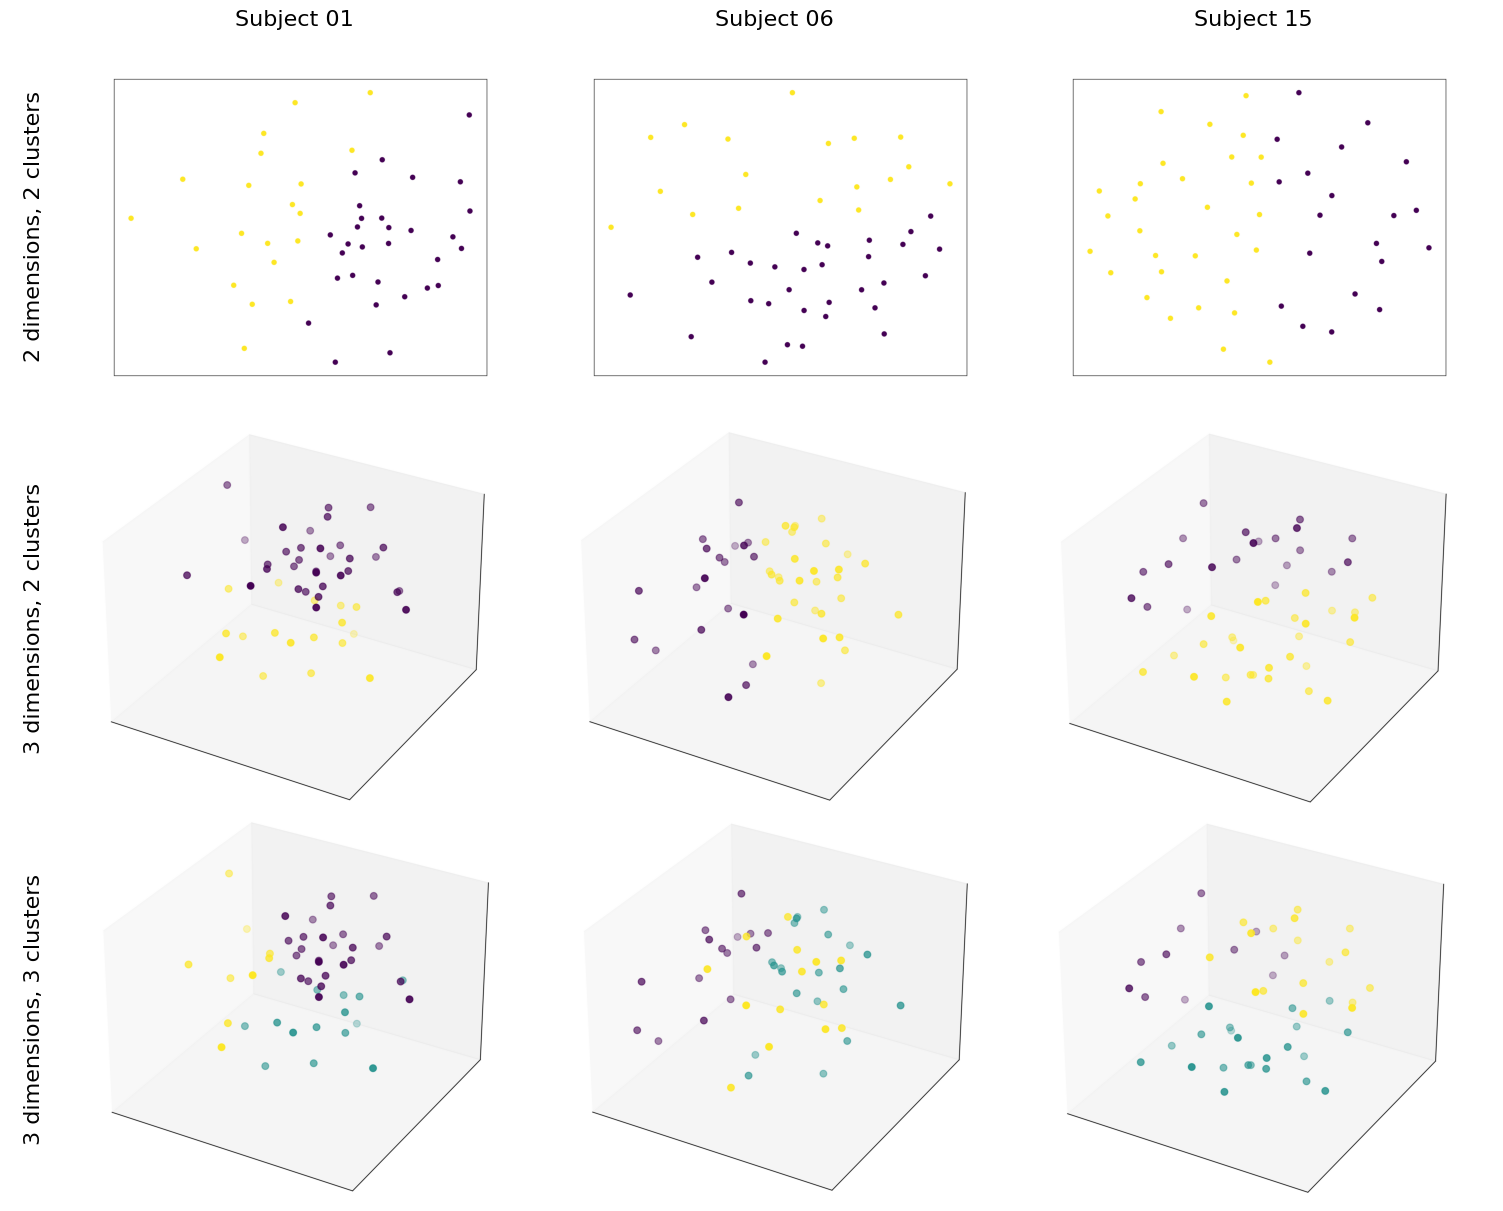

In [36]:
import os
import matplotlib.pyplot as plt
from glob import glob

# Define the runs and subjects
runs = ['run_19', 'run_20', 'run_21']
subjects = ['sub-01', 'sub-06', 'sub-15']
descriptions = ['2 dimensions, 2 clusters', '3 dimensions, 2 clusters', '3 dimensions, 3 clusters']

directory = '/home/hmueller2/ibc_code/ibc_output_MDS'

fig, axes = plt.subplots(3, 4, figsize=(15, 12), gridspec_kw={'width_ratios': [0.1, 1, 1, 1]})
for i, run in enumerate(runs):
    # Add a dummy subplot for description
    axes[i, 0].text(0.5, 0.5, descriptions[i], rotation=90, fontsize=16,  # Increased font size
                    horizontalalignment='center', verticalalignment='center')
    axes[i, 0].axis('off')
    
    for j, subject in enumerate(subjects, start=1):
        file_path = glob(os.path.join(directory, f'{run}/clusters_{subject}_*.png'))[0]
        img = plt.imread(file_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(f'Subject {subject.split("-")[1]}', fontsize=16)  # Increased font size

# Apply tight layout after the loops
plt.tight_layout(pad=0.5, w_pad=-0.5, h_pad=0.5)

# Save the figure with a transparent background
output_dir = '/home/hmueller2/ibc_code/ibc_latent/images_presentation/'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'mds_visualization.png')
plt.savefig(output_file, dpi=300, bbox_inches='tight', transparent=True)

# Optional: show the plot
plt.show()

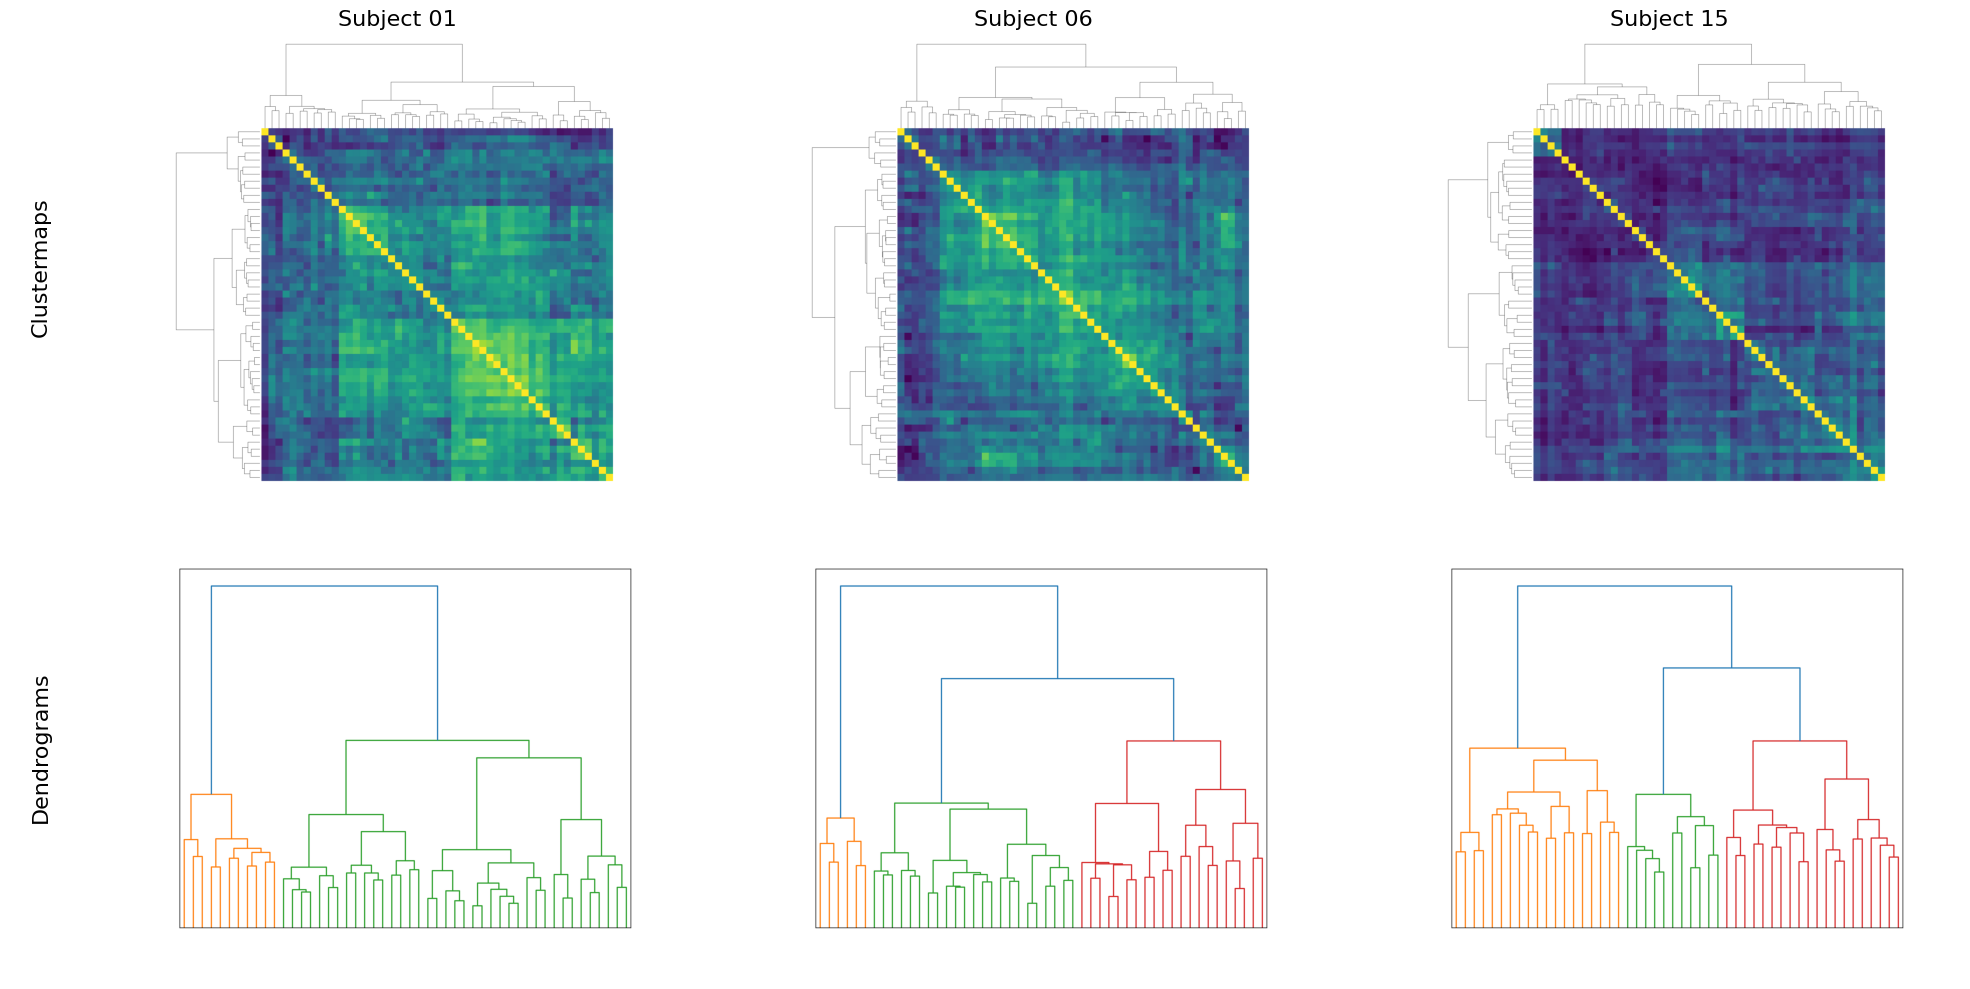

In [41]:
from matplotlib.image import imread

subjects = ['sub-01', 'sub-06', 'sub-15']
descriptions = ['Clustermaps', 'Dendrograms']

# Define the directory for clustermaps and dendrograms
clustermap_dir = '/home/hmueller2/ibc_code/ibc_output_Hierarchical'
dendrogram_dir = '/home/hmueller2/ibc_code/ibc_output_Hierarchical'

fig, axes = plt.subplots(2, len(subjects) + 1, figsize=(20, 10), gridspec_kw={'width_ratios': [0.1] + [1] * len(subjects)})

for row_idx, description in enumerate(descriptions):
    # Add the description text rotated 90 degrees
    axes[row_idx, 0].text(0.5, 0.5, description, rotation=90, fontsize=16,
                          horizontalalignment='center', verticalalignment='center')
    axes[row_idx, 0].axis('off')

for i, subject in enumerate(subjects):
    # Load and plot the clustermap
    clustermap_path = os.path.join(clustermap_dir, f'clustermap_{subject}.png')
    clustermap_img = imread(clustermap_path)
    axes[0, i + 1].imshow(clustermap_img)
    axes[0, i + 1].axis('off')
    axes[0, i + 1].set_title(f'Subject {subject.split("-")[1]}', fontsize=16)

    # Load and plot the dendrogram
    dendrogram_path = os.path.join(dendrogram_dir, f'dendrogram_{subject}.png')
    dendrogram_img = imread(dendrogram_path)
    axes[1, i + 1].imshow(dendrogram_img)
    axes[1, i + 1].axis('off')

plt.tight_layout()

# Save the figure with a transparent background
output_dir = '/home/hmueller2/ibc_code/ibc_latent/images_presentation/'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'hierarchical_visualization.png')
plt.savefig(output_file, dpi=300, bbox_inches='tight', transparent=True)

plt.show()


# Visualize Task representations between clusters

### 2 Clusters:

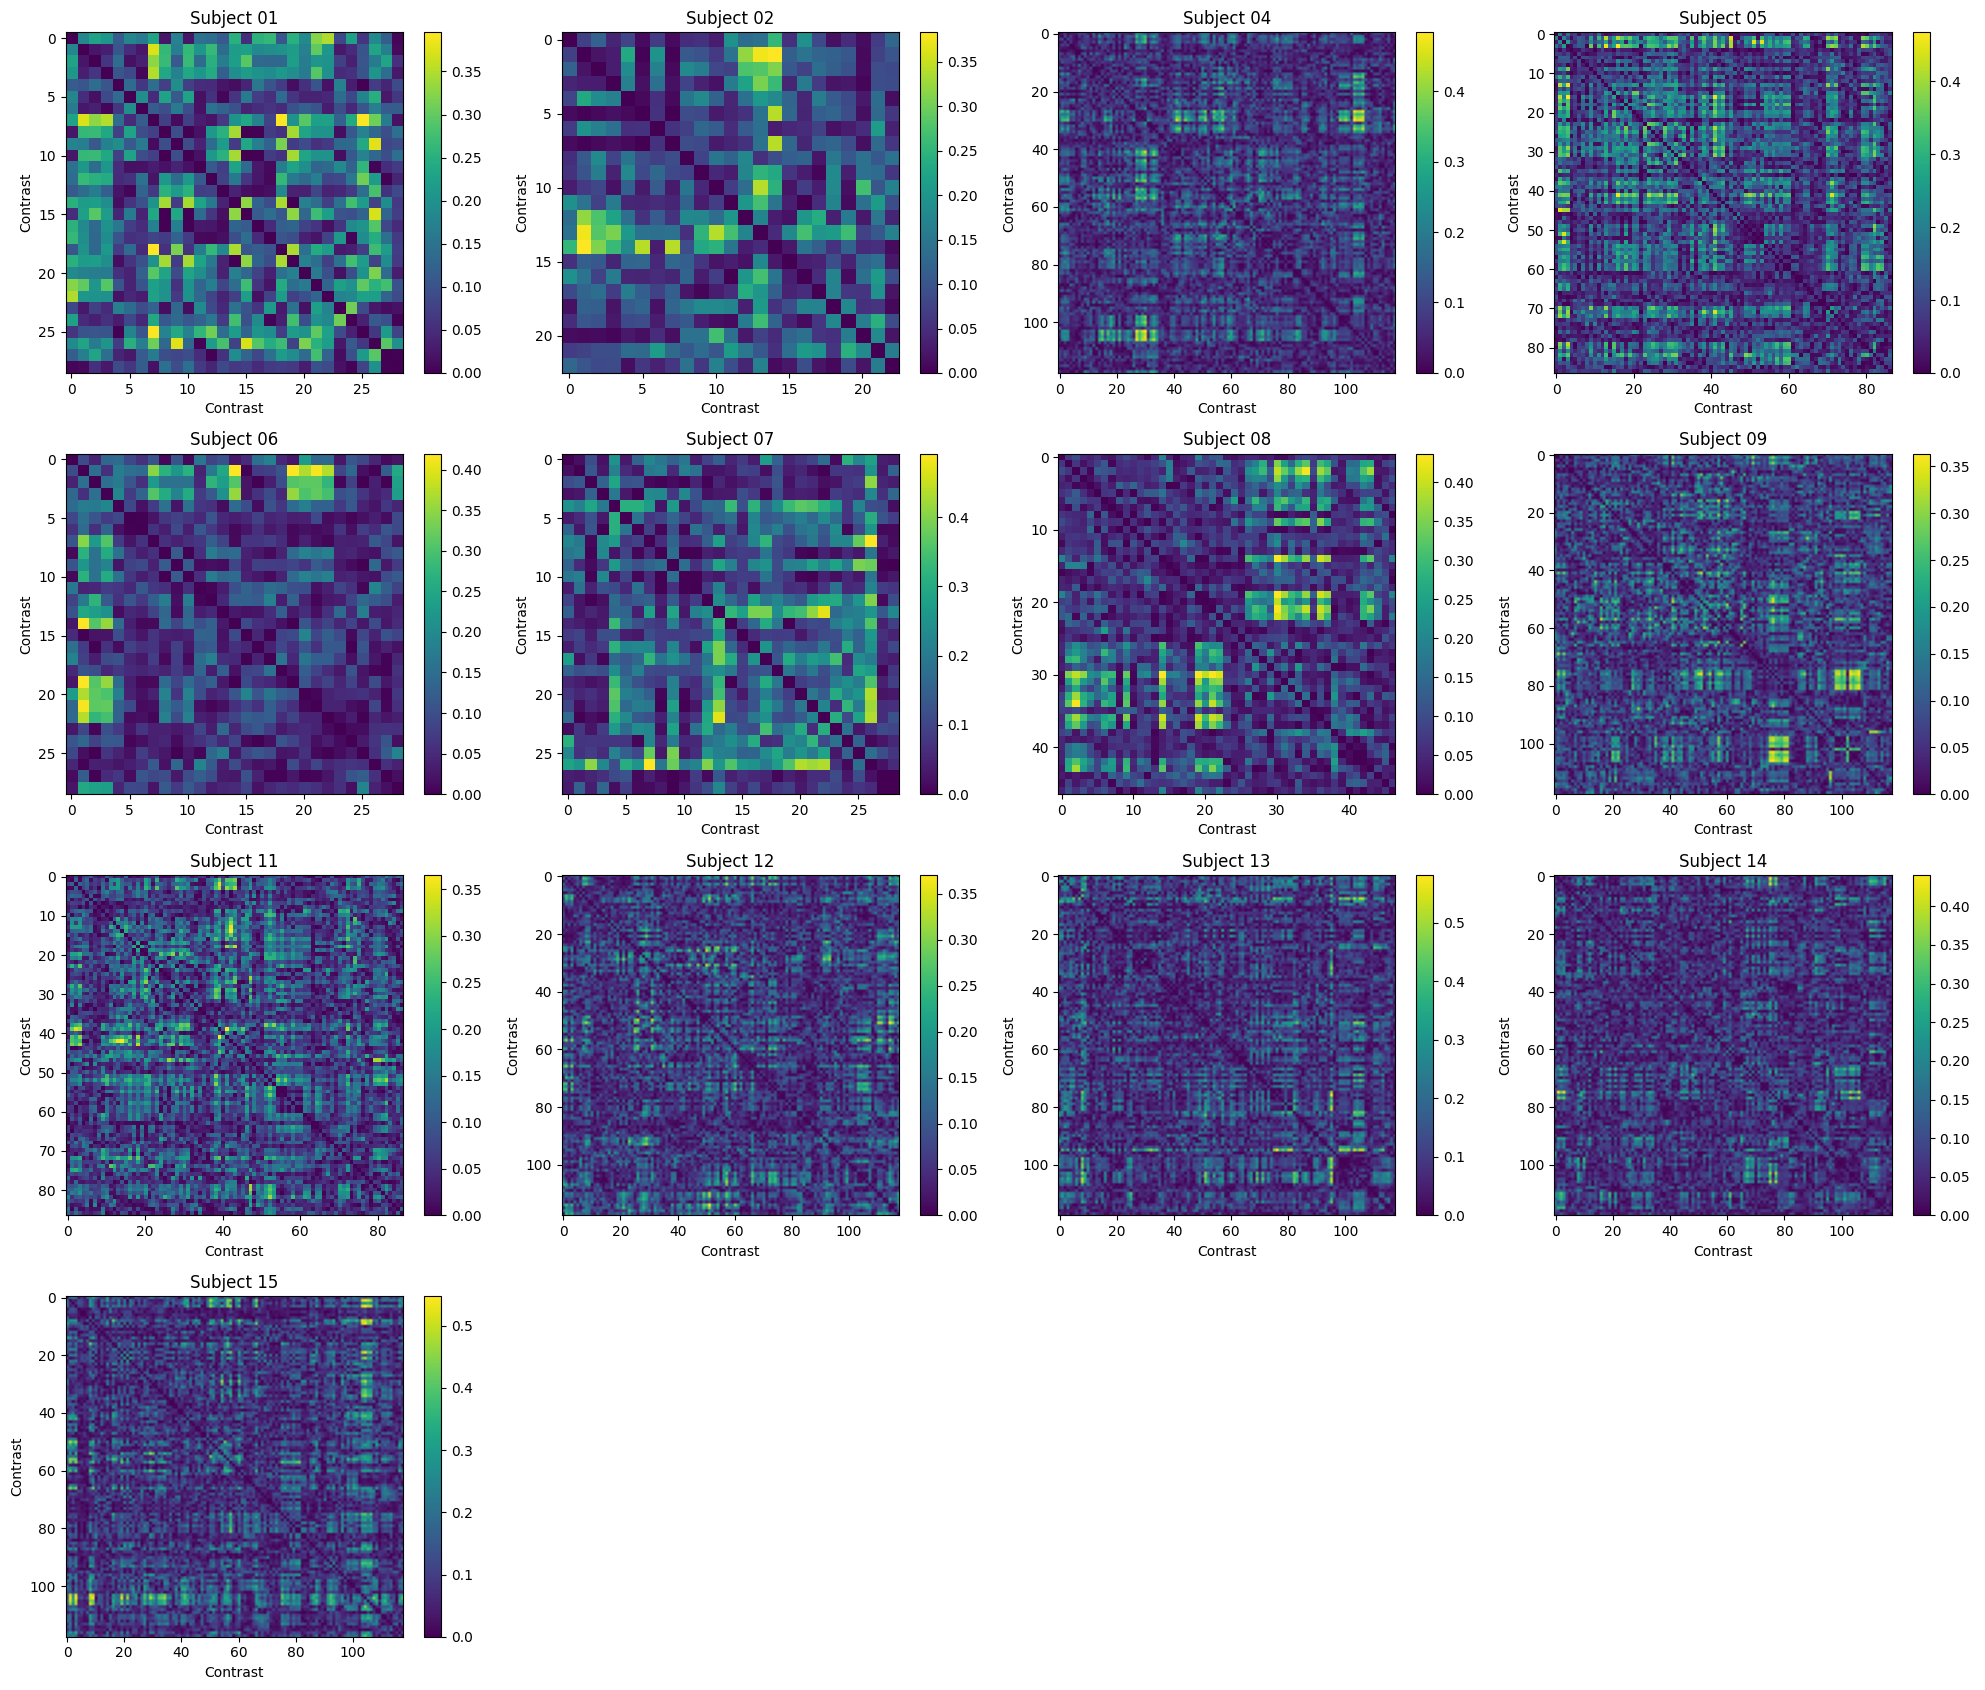

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.manifold import MDS

base_dir = '/home/hmueller2/ibc_code'

subjects = [f'sub-{i:02d}' for i in range(1, 16) if i not in [3, 10]]
run = '10'  # Specify the run
cluster1 = 1
cluster2 = 2

fig, axes = plt.subplots(4, 4, figsize=(20, 17))

for idx, subject in enumerate(subjects):
    row = idx // 4
    col = idx % 4
    # Load the Euclidean Distance data (Average_RSM_Cluster_1 - Average_RSM_Cluster_2)
    distance_file = os.path.join(base_dir, 'ibc_output_KMeans_onMDS', f'run_{run}', f'{cluster1}-{cluster2}_{subject}.csv')
    distance_data = np.loadtxt(distance_file, delimiter=',', skiprows=1)

    ax = axes[row, col]
    im = ax.imshow(distance_data, aspect='auto', cmap='viridis')
    ax.set_title(f'Subject {subject.split("-")[1]}')
    ax.set_xlabel('Contrast')
    ax.set_ylabel('Contrast')
    fig.colorbar(im, ax=ax)

# Hide any unused subplots
for idx in range(len(subjects), 16):
    row = idx // 4
    col = idx % 4
    axes[row, col].axis('off')

plt.tight_layout()
#plt.savefig('cluster_RSM_comparison.png', dpi=300)

plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_dir = '/home/hmueller2/ibc_code'

# Compute statistics for each subject's Euclidean distance matrices
subjects = [f'sub-{i:02d}' for i in range(1, 16) if i not in [3, 10]]
run = '10'  # Specify the run
cluster1 = 1
cluster2 = 2

for subject in subjects:
    # Load the Euclidean Distance data
    distance_file = os.path.join(base_dir, 'ibc_output_KMeans_onMDS', f'run_{run}', f'{cluster1}-{cluster2}_{subject}.csv')
    distances = np.loadtxt(distance_file, delimiter=',', skiprows=1)

    # Compute statistics
    min_dist = np.min(distances)
    max_dist = np.max(distances)
    mean_dist = np.mean(distances)
    std_dist = np.std(distances)

    # Print statistics for the subject
    print(f"Statistics for {subject}:")
    print(f"  Min Distance: {min_dist}")
    print(f"  Max Distance: {max_dist}")
    print(f"  Mean Distance: {mean_dist}")
    print(f"  Std Deviation: {std_dist}")
    print()

Statistics for sub-01:
  Min Distance: 0.0
  Max Distance: 0.3954426429407883
  Mean Distance: 0.13224420724703012
  Std Deviation: 0.09363011369572782

Statistics for sub-02:
  Min Distance: 0.0
  Max Distance: 0.38324151948131857
  Mean Distance: 0.1020735669759039
  Std Deviation: 0.08140333636810772

Statistics for sub-04:
  Min Distance: 0.0
  Max Distance: 0.48333385654855254
  Mean Distance: 0.08473841208861024
  Std Deviation: 0.06857335242819274

Statistics for sub-05:
  Min Distance: 0.0
  Max Distance: 0.46723057905551135
  Mean Distance: 0.11171216415118354
  Std Deviation: 0.08771468924152276

Statistics for sub-06:
  Min Distance: 0.0
  Max Distance: 0.4196122294279861
  Mean Distance: 0.08474234552595336
  Std Deviation: 0.07903902679088987

Statistics for sub-07:
  Min Distance: 0.0
  Max Distance: 0.4917921191423897
  Mean Distance: 0.13525192960620122
  Std Deviation: 0.1054464917737561

Statistics for sub-08:
  Min Distance: 0.0
  Max Distance: 0.4369354861684057
  M

In [6]:
# Initialize lists to store mean and standard deviation for each subject
mean_distances = []
std_distances = []

for subject in subjects:
    # Load the Euclidean Distance data
    distance_file = os.path.join(base_dir, 'ibc_output_KMeans_onMDS', f'run_{run}', f'{cluster1}-{cluster2}_{subject}.csv')
    distances = np.loadtxt(distance_file, delimiter=',', skiprows=1)

    # Compute statistics
    mean_distances.append(np.mean(distances))
    std_distances.append(np.std(distances))

# Compute the range of differences
range_of_means = (np.min(mean_distances), np.max(mean_distances))
range_of_stds = (np.min(std_distances), np.max(std_distances))

# Compute the average mean and standard deviation across all subjects
average_mean = np.mean(mean_distances)
average_std = np.mean(std_distances)

print(f"Range of Means: {range_of_means}")
print(f"Range of Standard Deviations: {range_of_stds}")
print(f"Average Mean Distance: {average_mean}")
print(f"Average Standard Deviation: {average_std}")

lowest_mean = min(mean_distances)
highest_mean = max(mean_distances)

lowest_std = min(std_distances)
highest_std = max(std_distances)

print(f"Lowest Mean Distance: {lowest_mean}")
print(f"Highest Mean Distance: {highest_mean}")
print(f"Lowest Standard Deviation: {lowest_std}")
print(f"Highest Standard Deviation: {highest_std}")


Range of Means: (np.float64(0.07103385555687274), np.float64(0.13525192960620122))
Range of Standard Deviations: (np.float64(0.05587926806172837), np.float64(0.1054464917737561))
Average Mean Distance: 0.0963946877189868
Average Standard Deviation: 0.07748818237493435
Lowest Mean Distance: 0.07103385555687274
Highest Mean Distance: 0.13525192960620122
Lowest Standard Deviation: 0.05587926806172837
Highest Standard Deviation: 0.1054464917737561


In [ ]:
# Define the number of parcels and clusters
num_parcels = 50
num_clusters = 2

# Simulate cluster assignments for each subject (replace this with actual data)
# Example: cluster_assignments[parcel][subject] = cluster_id
cluster_assignments = np.random.randint(1, num_clusters + 1, size=(num_parcels, len(subjects)))

# Count parcels assigned to the same cluster in at least two subjects
consistent_parcels = 0

for parcel in range(num_parcels):
    cluster_counts = np.bincount(cluster_assignments[parcel], minlength=num_clusters + 1)[1:]
    if np.any(cluster_counts >= 2):  # Check if any cluster has at least two assignments
        consistent_parcels += 1

# Compute the percentage of consistent parcels
percentage_consistent = (consistent_parcels / num_parcels) * 100

print(f"Percentage of parcels assigned to the same cluster in at least two subjects: {percentage_consistent:.2f}%")

### 3 Clusters:

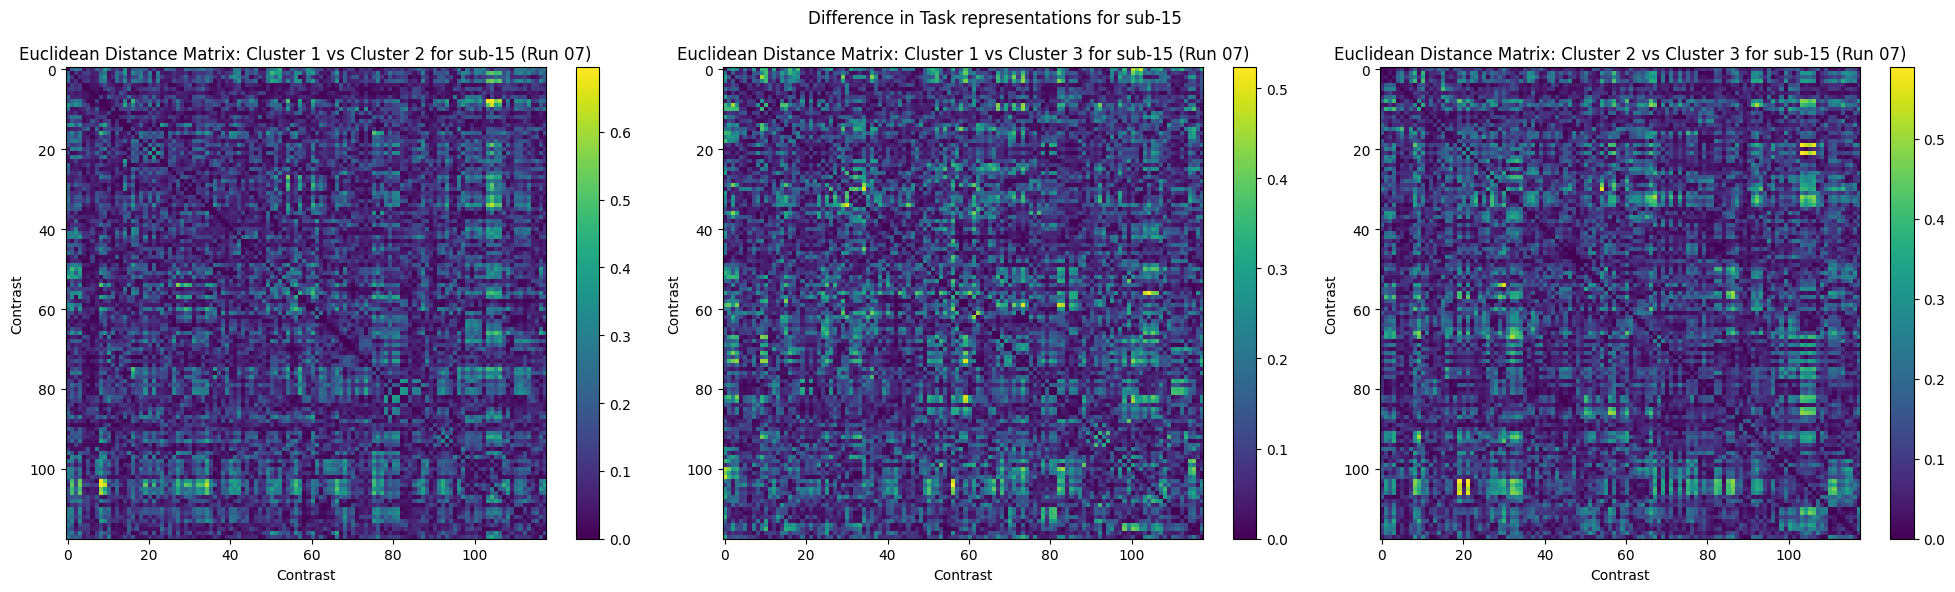

In [5]:
subject = 'sub-15'  # Specify the subject
run = '07'  # Specify the run
cluster1 = 1
cluster2 = 2
cluster3 = 3

# Load the Euclidean Distance data for Cluster 1-2, 1-3, and 2-3
distance_file_1_2 = os.path.join(base_dir, 'ibc_output_KMeans_onMDS', f'run_{run}', f'{cluster1}-{cluster2}_{subject}.csv')
distance_file_1_3 = os.path.join(base_dir, 'ibc_output_KMeans_onMDS', f'run_{run}', f'{cluster1}-{cluster3}_{subject}.csv')
distance_file_2_3 = os.path.join(base_dir, 'ibc_output_KMeans_onMDS', f'run_{run}', f'{cluster2}-{cluster3}_{subject}.csv')

distance_data_1_2 = np.loadtxt(distance_file_1_2, delimiter=',', skiprows=1)
distance_data_1_3 = np.loadtxt(distance_file_1_3, delimiter=',', skiprows=1)
distance_data_2_3 = np.loadtxt(distance_file_2_3, delimiter=',', skiprows=1)

plt.figure(figsize=(20, 6))
plt.suptitle(f'Difference in Task representations for {subject}')

plt.subplot(1, 3, 1)
plt.imshow(distance_data_1_2, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title(f'Euclidean Distance Matrix: Cluster {cluster1} vs Cluster {cluster2} for {subject} (Run {run})')
plt.xlabel('Contrast')
plt.ylabel('Contrast')

plt.subplot(1, 3, 2)
plt.imshow(distance_data_1_3, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title(f'Euclidean Distance Matrix: Cluster {cluster1} vs Cluster {cluster3} for {subject} (Run {run})')
plt.xlabel('Contrast')
plt.ylabel('Contrast')

plt.subplot(1, 3, 3)
plt.imshow(distance_data_2_3, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title(f'Euclidean Distance Matrix: Cluster {cluster2} vs Cluster {cluster3} for {subject} (Run {run})')
plt.xlabel('Contrast')
plt.ylabel('Contrast')

plt.tight_layout()
plt.show()

In [ ]:
subjects = [f'sub-{i:02d}' for i in range(1, 16) if i not in [3, 10]]
run = '07'  # Specify the run
cluster1 = 1
cluster2 = 2
cluster3 = 3

fig, axes = plt.subplots(len(subjects), 3, figsize=(20, 6 * len(subjects)))

for idx, subject in enumerate(subjects):
    distance_file_1_2 = os.path.join(base_dir, 'ibc_output_KMeans_onMDS', f'run_{run}', f'{cluster1}-{cluster2}_{subject}.csv')
    distance_file_1_3 = os.path.join(base_dir, 'ibc_output_KMeans_onMDS', f'run_{run}', f'{cluster1}-{cluster3}_{subject}.csv')
    distance_file_2_3 = os.path.join(base_dir, 'ibc_output_KMeans_onMDS', f'run_{run}', f'{cluster2}-{cluster3}_{subject}.csv')

    distance_data_1_2 = np.loadtxt(distance_file_1_2, delimiter=',', skiprows=1)
    distance_data_1_3 = np.loadtxt(distance_file_1_3, delimiter=',', skiprows=1)
    distance_data_2_3 = np.loadtxt(distance_file_2_3, delimiter=',', skiprows=1)

    im1 = axes[idx, 0].imshow(distance_data_1_2, aspect='auto', cmap='viridis')
    axes[idx, 0].set_title(f'Cluster {cluster1} vs Cluster {cluster2}\n{subject} (Run {run})')
    axes[idx, 0].set_xlabel('Contrast')
    axes[idx, 0].set_ylabel('Contrast')
    fig.colorbar(im1, ax=axes[idx, 0])

    im2 = axes[idx, 1].imshow(distance_data_1_3, aspect='auto', cmap='viridis')
    axes[idx, 1].set_title(f'Cluster {cluster1} vs Cluster {cluster3}\n{subject} (Run {run})')
    axes[idx, 1].set_xlabel('Contrast')
    axes[idx, 1].set_ylabel('Contrast')
    fig.colorbar(im2, ax=axes[idx, 1])

    im3 = axes[idx, 2].imshow(distance_data_2_3, aspect='auto', cmap='viridis')
    axes[idx, 2].set_title(f'Cluster {cluster2} vs Cluster {cluster3}\n{subject} (Run {run})')
    axes[idx, 2].set_xlabel('Contrast')
    axes[idx, 2].set_ylabel('Contrast')
    fig.colorbar(im3, ax=axes[idx, 2])

plt.tight_layout()
plt.show()

In [18]:
def load_contrast_names(file_path):
    with open(file_path, 'r') as file:
        contrast_names = file.read().splitlines()
    return contrast_names

# Load contrast names for the given subject
subject = 'sub-12'  # Specify the subject
contrast_file = f'/home/hmueller2/ibc_code/ibc_output_RSA_cosine/{subject}/contrast_names_{subject}.txt'
contrast_names = load_contrast_names(contrast_file)

# Find the indices of the maximum dissimilarity in each distance matrix
max_idx_1_2 = np.unravel_index(np.argmax(distance_data_1_2, axis=None), distance_data_1_2.shape)
max_idx_1_3 = np.unravel_index(np.argmax(distance_data_1_3, axis=None), distance_data_1_3.shape)
max_idx_2_3 = np.unravel_index(np.argmax(distance_data_2_3, axis=None), distance_data_2_3.shape)

# Output the top 4 task contrasts with the highest dissimilarity for each cluster comparison
def get_top_dissimilarities(distance_data, contrast_names, top_n=4):
    flat_indices = np.argsort(distance_data, axis=None)[-top_n:]
    top_indices = [np.unravel_index(idx, distance_data.shape) for idx in flat_indices]
    top_dissimilarities = [(contrast_names[i], contrast_names[j], distance_data[i, j]) for i, j in top_indices]
    return top_dissimilarities

top_1_2 = get_top_dissimilarities(distance_data_1_2, contrast_names)
top_1_3 = get_top_dissimilarities(distance_data_1_3, contrast_names)
top_2_3 = get_top_dissimilarities(distance_data_2_3, contrast_names)

print("Top 4 dissimilarities in Cluster 1 vs Cluster 2:")
for contrast1, contrast2, value in top_1_2:
    print(f"{contrast1} vs {contrast2}: {value}")

print("\nTop 4 dissimilarities in Cluster 1 vs Cluster 3:")
for contrast1, contrast2, value in top_1_3:
    print(f"{contrast1} vs {contrast2}: {value}")

print("\nTop 4 dissimilarities in Cluster 2 vs Cluster 3:")
for contrast1, contrast2, value in top_2_3:
    print(f"{contrast1} vs {contrast2}: {value}")